In [2]:
# Paso 2: Importar librerías
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import load_dataset, Dataset
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np
import torch

# Paso 3: Cargar y preparar el dataset
df = pd.read_csv("dataset_limpio.csv")  # Reemplaza por tu ruta si es necesario

# Nos centramos solo en las columnas necesarias
df = df[["text", "category"]].dropna()

# Codificar etiquetas
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["category"])

# Guardar las etiquetas para decodificar luego
label2id = {label: i for i, label in enumerate(label_encoder.classes_)}
id2label = {i: label for label, i in label2id.items()}

# Paso 4: Crear Dataset de Hugging Face
dataset = Dataset.from_pandas(df[["text", "label"]].rename(columns={"text": "text", "label": "label"}))

# Paso 5: Tokenización
model_name = "pysentimiento/robertuito-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(batch["text"], padding=True, truncation=True)

dataset = dataset.map(tokenize, batched=True)

# División entrenamiento y validación
dataset = dataset.train_test_split(test_size=0.2)

# Paso 6: Cargar modelo preentrenado
num_labels = len(label2id)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels, id2label=id2label, label2id=label2id)

# Paso 7: Configurar entrenamiento
training_args = TrainingArguments(
    output_dir="./modelo_categoria",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=6,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10
)

# Paso 8: Función de evaluación
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="weighted")
    return {"accuracy": acc, "f1": f1}

# Paso 9: Entrenador
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

# Paso 10: Entrenar
trainer.train()

# Paso 11: Guardar el modelo
trainer.save_model("./modelo_categoria")
tokenizer.save_pretrained("./modelo_categoria")

c:\Users\Usuario\Desktop\MailClassifier\.venv\lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Map:   0%|          | 0/223 [00:00<?, ? examples/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at pysentimiento/robertuito-base-uncased and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/138 [00:00<?, ?it/s]

c:\Users\Usuario\Desktop\MailClassifier\.venv\lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


...

c:\Users\Usuario\Desktop\MailClassifier\.venv\lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 0.4052, 'grad_norm': 7.357301235198975, 'learning_rate': 2.6086956521739132e-06, 'epoch': 5.22}
{'loss': 0.3959, 'grad_norm': 4.099307060241699, 'learning_rate': 1.1594202898550726e-06, 'epoch': 5.65}


  0%|          | 0/6 [00:00<?, ?it/s]

{'eval_loss': 0.5608339309692383, 'eval_accuracy': 0.8666666666666667, 'eval_f1': 0.8643258495890074, 'eval_runtime': 0.4208, 'eval_samples_per_second': 106.938, 'eval_steps_per_second': 14.258, 'epoch': 6.0}
{'train_runtime': 76.6904, 'train_samples_per_second': 13.926, 'train_steps_per_second': 1.799, 'train_loss': 0.7212800789570463, 'epoch': 6.0}


('./modelo_categoria\\tokenizer_config.json',
 './modelo_categoria\\special_tokens_map.json',
 './modelo_categoria\\tokenizer.json')

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


=== Reporte clasificación Category ===
              precision    recall  f1-score   support

   comercial       0.92      0.96      0.94        51
        otro       0.98      0.93      0.96        46
       queja       0.92      1.00      0.96        69
   solicitud       0.94      0.84      0.89        57

    accuracy                           0.94       223
   macro avg       0.94      0.93      0.94       223
weighted avg       0.94      0.94      0.94       223



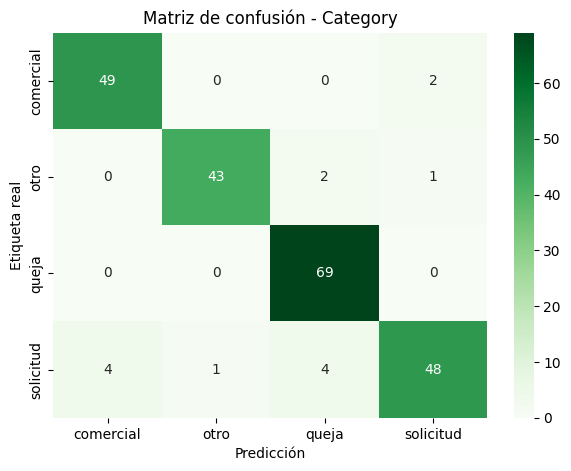

In [5]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import pandas as pd
import numpy as np
import torch

df = pd.read_csv("dataset_limpio.csv")
df = df[["text", "category"]].dropna()

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["category"])

labels = label_encoder.classes_

tokenizer = AutoTokenizer.from_pretrained("./modelo_categoria")
model = AutoModelForSequenceClassification.from_pretrained("./modelo_categoria")

tokens = tokenizer(df["text"].tolist(), padding=True, truncation=True, return_tensors="pt")

with torch.no_grad():
    outputs = model(**tokens)
preds = torch.argmax(outputs.logits, axis=1).numpy()

print("=== Reporte clasificación Category ===")
print(classification_report(df["label"], preds, target_names=labels))

cm = confusion_matrix(df["label"], preds)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Greens")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de confusión - Category")
plt.show()


In [3]:
from transformers import pipeline
import pandas as pd

# Cargar modelo y tokenizer ya entrenados
clf = pipeline("text-classification", model="./modelo_categoria", tokenizer="./modelo_categoria")

# Lista de pruebas: (texto, categoría esperada)
ejemplos = [
    ("Mi pedido no ha llegado y ya pasaron 10 días", "queja"),
    ("¿Pueden confirmarme si tienen stock del producto?", "solicitud"),
    ("Estamos interesados en su oferta para empresas", "comercial"),
    ("Gracias por la atención, todo perfecto", "otro"),
    ("Solicito el número de seguimiento del pedido", "solicitud"),
    ("Recibí el producto roto y nadie contesta", "queja"),
    ("¿Ofrecen descuentos para distribuidores?", "comercial"),
    ("Todo ha ido perfecto, gracias", "otro"),
    ("Quiero programar una reunión comercial", "comercial"),
    ("Me gustaría confirmar si el producto tiene garantía", "solicitud"),
]

# Ejecutar predicciones
print(f"{'Texto':<60} | {'Esperado':<10} | {'Predicción':<10} | {'Score'}")
print("-" * 100)

for texto, esperado in ejemplos:
    pred = clf(texto)[0]
    print(f"{texto[:57]:<60} | {esperado:<10} | {pred['label']:<10} | {pred['score']:.4f}")


Texto                                                        | Esperado   | Predicción | Score
----------------------------------------------------------------------------------------------------
Mi pedido no ha llegado y ya pasaron 10 días                 | queja      | queja      | 0.8492
¿Pueden confirmarme si tienen stock del producto?            | solicitud  | solicitud  | 0.5591
Estamos interesados en su oferta para empresas               | comercial  | comercial  | 0.8952
Gracias por la atención, todo perfecto                       | otro       | otro       | 0.7990
Solicito el número de seguimiento del pedido                 | solicitud  | solicitud  | 0.8269
Recibí el producto roto y nadie contesta                     | queja      | queja      | 0.8825
¿Ofrecen descuentos para distribuidores?                     | comercial  | comercial  | 0.8675
Todo ha ido perfecto, gracias                                | otro       | otro       | 0.7804
Quiero programar una reunión comerci